### Práctica 4
Este código nos diseña el controlador PID de la práctica 4 de Control para el motor.

Importemos las librerías a utilizar primero

In [1]:
import control
import numpy as np
import matplotlib.pyplot as plt

Ahora, definamos la función de transferencia de la planta:

In [2]:
num = [395]
den = [0.141, 1]
G = control.tf(num, den)
print(G)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      395
  -----------
  0.141 s + 1


Ahora, coloquemos las especificaciones de diseño

In [3]:
SP = 5 #5%
zeta = abs(np.log(SP/100)) / np.sqrt(np.log(SP/100)**2 + np.pi**2)
tr = 0.5 #s 
wn = (2.23*zeta**2+0.036*zeta+1.54)/tr # rad/s
print(wn)
print(zeta)

5.253750640655597
0.6901067305598217


### Control por localización de polos

Hallemos el orden

In [4]:
n = 1
gl = 1
q = 2*n - 1 + gl
m = 1

print("Entonces el polinomio de lazo cerrado es de orden:", q)

Entonces el polinomio de lazo cerrado es de orden: 2


Como buscamos PID, necesitamos controlador de la forma
$$
C(s) = \frac{B_1 s + B_0}{(s + A_0)}
$$

Recuerde que los polos de un sistema de segundo orden están dandos por:

$$
s_{1,2} = -\zeta \omega_n \pm j \, \omega_n \sqrt{1 - \zeta^2}
$$

Esto quiere decir que para este caso, tenemos que:

In [5]:
real = -zeta*wn 
imag = wn * np.sqrt(1 -  zeta**2)
s1 = real +1j*imag
s2 = real - 1j*imag
print("Polo 1 es: ", s1)
print("Polo 2 es: ", s2)

DT = np.poly([s1, s2])
print("Coeficientes de D_T(s):", DT)

Polo 1 es:  (-3.6256486777994033+3.8021793039466902j)
Polo 2 es:  (-3.6256486777994033-3.8021793039466902j)
Coeficientes de D_T(s): [ 1.          7.25129736 27.60189579]


### Paso 3: Plantear la ecuación

Con

$$
G(s) = \frac{N(s)}{D(s)} = \frac{395}{0.141s + 1}
$$

y el controlador

$$
C(s) = \frac{B_1 s + B_0}{s + A_0}
$$

la condición es:

$$
D_T(s) = A(s)D(s) + B(s)N(s)
$$

$$
(s + A_0)(0.141s + 1) + (B_1 s + B_0)\cdot 395 = s^2 + 7.25s + 27.60
$$

Expandiendo e igualando coeficientes por potencia de $s$:

| Potencia | Ecuación |
|----------|---------|
| $s^2$  | $0.141(1+A0​)=1$ |
| $s^1$  | $(1+A0​)+395B1​=7.25$ |
| $s^0$  | $395B_0 = 27.60$ |

In [6]:
# A_mat = np.array([
#     [0.141, 0,   0],
#     [1+0.141,     395, 0],
#     [0,     0,   395]
# ])

A0 = 0

A_mat = np.array([
    [395,0],
    [0, 395]
])

b_vec = np.array([
    DT[1] - 1,   # con A0=0
    DT[2]        # con A0=0
])

# b_vec = np.array([
#     1-0.141,
#     7.25 - 1,
#     27.60
# ])

B1, B0 = np.linalg.solve(A_mat, b_vec)

print(A0, B1, B0)

C = control.tf([B1, B0], [1, A0])
print(C)



0 0.01582606925468052 0.06987821720047872
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.01583 s + 0.06988
  -------------------
           s


Finalmente, probemos el sistema en lazo cerrado

Polos del sistema de lazo cerrado [-47.28793531+0.j  -4.13970551+0.j]
DT deseado: [ 1.          7.25129736 27.60189579]
Denominador real: [[array([ 0.141     ,  7.25129736, 27.60189579])]]


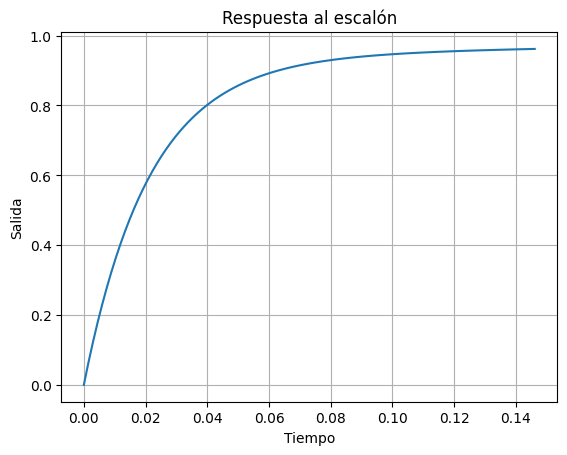

In [7]:
T = control.feedback(C*G,1)
print("Polos del sistema de lazo cerrado", control.poles(T))
print("DT deseado:", DT)
print("Denominador real:", T.den)

t, y = control.step_response(T)
plt.plot(t,y)
plt.grid()
plt.title("Respuesta al escalón")
plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.show()